In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [2]:
if tf.config.list_physical_devices('GPU'):
    print("✓ GPU mil gaya - Fast training hogi!")
else:
    print("ℹ GPU nahi mila - CPU use hoga")

✓ GPU mil gaya - Fast training hogi!


In [3]:
vocab_size = 10000      # Kitne words use karne hain
max_length = 200        # Review kitna lamba ho sakta hai
embedding_dim = 128     # Word embedding ka size
lstm_units = 64         # LSTM layer me kitne neurons
batch_size = 128        # Ek baar me kitne reviews train karna
epochs = 10             # Kitni baar pura data dekhna hai


In [4]:
print(f"  Vocabulary size: {vocab_size}")
print(f"  Max review length: {max_length}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  LSTM units: {lstm_units}")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {epochs}")


  Vocabulary size: 10000
  Max review length: 200
  Embedding dimension: 128
  LSTM units: 64
  Batch size: 128
  Epochs: 10


In [5]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print(f"  Training reviews: {len(X_train)}")
print(f"  Testing reviews: {len(X_test)}")
print(f"  Total reviews: {len(X_train) + len(X_test)}")

  Training reviews: 25000
  Testing reviews: 25000
  Total reviews: 50000


In [14]:
len(X_train[5])

43

In [7]:
print(f"  Length: {len(X_train[0])} words")
print(f"  Label: {y_train[0]} (0=Negative, 1=Positive)")
print(f"  First 10 words (encoded): {X_train[0][:10]}")

  Length: 218 words
  Label: 1 (0=Negative, 1=Positive)
  First 10 words (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


In [15]:
negative_count = np.sum(y_train == 0)
positive_count = np.sum(y_train == 1)

In [16]:
print(f"  Negative reviews: {negative_count} ({negative_count/len(y_train)*100:.1f}%)")
print(f"  Positive reviews: {positive_count} ({positive_count/len(y_train)*100:.1f}%)")

  Negative reviews: 12500 (50.0%)
  Positive reviews: 12500 (50.0%)


In [17]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
reverse_word_index = {}
for word, index in word_index.items():
    reverse_word_index[index + 3] = word

In [19]:
reverse_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

In [20]:
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'

In [21]:
print(f"  Total words in dictionary: {len(word_index)}")

  Total words in dictionary: 88584


In [23]:
len(X_train[0])

218

In [22]:
decoded_review = ""
for num in X_train[0]:
    if num != 0:  # Padding skip karo
        decoded_review += reverse_word_index.get(num, '?') + " "

print(f"\nDecoded review (pehle 200 characters):")
print(f"{decoded_review[:200]}...")
print(f"\nLabel: {'Positive' if y_train[0] == 1 else 'Negative'}")


Decoded review (pehle 200 characters):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and ...

Label: Positive


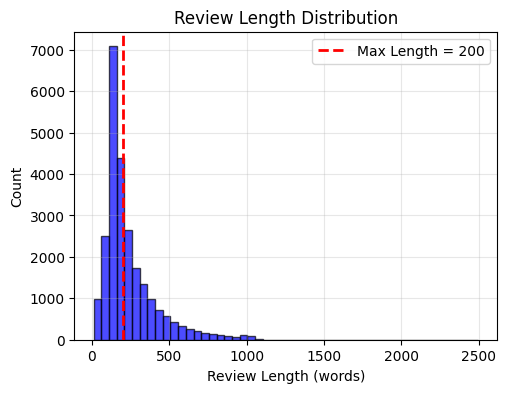

In [24]:
review_lengths = []
for review in X_train:
    review_lengths.append(len(review))

# Plot banao
plt.figure(figsize=(12, 4))

# Plot 1: Review lengths
plt.subplot(1, 2, 1)
plt.hist(review_lengths, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length = {max_length}')
plt.xlabel('Review Length (words)')
plt.ylabel('Count')
plt.title('Review Length Distribution')
plt.legend()
plt.grid(True, alpha=0.3)


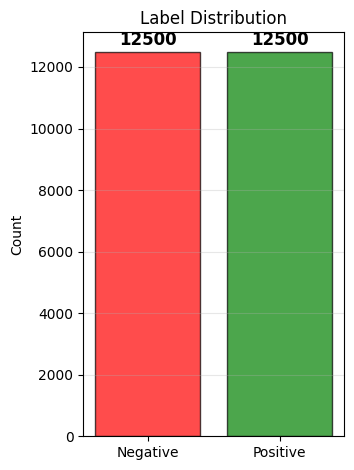

In [25]:
# Plot 2: Label distribution
plt.subplot(1, 2, 2)
labels = ['Negative', 'Positive']
counts = [negative_count, positive_count]
colors = ['red', 'green']
plt.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.grid(True, alpha=0.3, axis='y')

# Numbers add karo bars pe
for i, count in enumerate(counts):
    plt.text(i, count + 200, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

In [26]:
X_train_padded = sequence.pad_sequences(X_train, maxlen=max_length)
X_test_padded = sequence.pad_sequences(X_test, maxlen=max_length)

print(f"\n✓ Padding complete!")
print(f"  X_train shape: {X_train_padded.shape}")
print(f"  X_test shape: {X_test_padded.shape}")

# Example dekho
print(f"\nPehle review me padding:")
print(f"  Original length: {len(X_train[0])}")
print(f"  Padded length: {len(X_train_padded[0])}")
print(f"  Padded review start: {X_train_padded[0][:10]}")
print(f"  Padded review end: {X_train_padded[0][-10:]}")


✓ Padding complete!
  X_train shape: (25000, 200)
  X_test shape: (25000, 200)

Pehle review me padding:
  Original length: 218
  Padded length: 200
  Padded review start: [  5  25 100  43 838 112  50 670   2   9]
  Padded review end: [4472  113  103   32   15   16 5345   19  178   32]


In [28]:
X_train_padded[2]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    1,   14,   47,    8,   30,   31,    7,
          4,  249,  108,    7,    4, 5974,   54,   61,  369,   13,   71,
        149,   14,   22,  112,    4, 2401,  311,   12,   16, 3711,   33,
         75,   43, 1829,  296,    4,   86,  320,   35,  534,   19,  263,
       4821, 1301,    4, 1873,   33,   89,   78,   12,   66,   16,    4,
        360,    7,    4,   58,  316,  334,   11,    4, 1716,   43,  645,
        662,    8,  257,   85, 1200,   42, 1228, 2578,   83,   68, 3912,
         15,   36,  165, 1539,  278,   36,   69,    2,  780,    8,  106,
         14, 6905, 1338,   18,    6,   22,   12,  2

In [29]:
model = Sequential()

# Layer 1: Embedding layer - words ko numbers se vectors me convert karta hai
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# Layer 2: Bidirectional LSTM - aage aur peeche dono taraf se data padhta hai
model.add(Bidirectional(LSTM(lstm_units, return_sequences=True)))

# Layer 3: Dropout - overfitting rokne ke liye
model.add(Dropout(0.5))

# Layer 4: Ek aur Bidirectional LSTM layer
model.add(Bidirectional(LSTM(lstm_units // 2)))

# Layer 5: Dropout layer
model.add(Dropout(0.5))

# Layer 6: Dense layer - fully connected layer
model.add(Dense(64, activation='relu'))

# Layer 7: Dropout
model.add(Dropout(0.3))

# Layer 8: Output layer - final prediction (0 ya 1)
model.add(Dense(1, activation='sigmoid'))

In [30]:
model.build(input_shape=(None, max_length))

# Model ki puri details print karo
model.summary()

# Parameters count karo
total_params = model.count_params()
print(f"\n✓ Total parameters: {total_params:,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)


✓ Total parameters: 1,424,257


In [33]:
# Model ko compile karo - optimizer, loss function, aur metrics set karo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint - best model save karo
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Learning rate reduction - agar learning slow ho to LR kam karo
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# Sab callbacks ko ek list me dalo
callbacks = [early_stop, checkpoint, reduce_lr]

In [35]:
history = model.fit(
    X_train_padded,           # Training data
    y_train,                  # Training labels
    epochs=epochs,            # Kitni baar train karna
    batch_size=batch_size,    # Batch size
    validation_split=0.2,     # 20% data validation ke liye
    callbacks=callbacks,      # Callbacks use karo
    verbose=1                 # Progress dikhao
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6222 - loss: 0.6151
Epoch 1: val_accuracy improved from -inf to 0.85000, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.6229 - loss: 0.6145 - val_accuracy: 0.8500 - val_loss: 0.3535 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8941 - loss: 0.2787
Epoch 2: val_accuracy improved from 0.85000 to 0.87380, saving model to best_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8941 - loss: 0.2787 - val_accuracy: 0.8738 - val_loss: 0.3143 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9386 - loss: 0.1747
Epoch 3: val_accuracy did not improve from 0.87380
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9386 - loss: 0.1747 - val_accuracy: 0.8680 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 4/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9629 - loss: 0.1167
Epoch 4: val_accuracy did not improve from 0.87380

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9629 - loss: 0.1168 - val_accuracy: 0.8472 - val_loss: 0.4639 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9783 - loss: 0.0699
Epoch 5: val_accuracy did not improve from 0.87380
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9783 - loss: 0.0699 - val_

In [36]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

In [37]:
print(f"\nFinal Results:")
print(f"  Training Accuracy: {final_train_accuracy:.4f} ({final_train_accuracy*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_accuracy:.4f} ({final_val_accuracy*100:.2f}%)")
print(f"  Training Loss: {final_train_loss:.4f}")
print(f"  Validation Loss: {final_val_loss:.4f}")


Final Results:
  Training Accuracy: 0.9808 (98.08%)
  Validation Accuracy: 0.8644 (86.44%)
  Training Loss: 0.0666
  Validation Loss: 0.5019


In [38]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_accuracy = max(history.history['val_accuracy'])
print(f"\n  Best Validation Accuracy: {best_accuracy:.4f} at epoch {best_epoch}")


  Best Validation Accuracy: 0.8738 at epoch 2


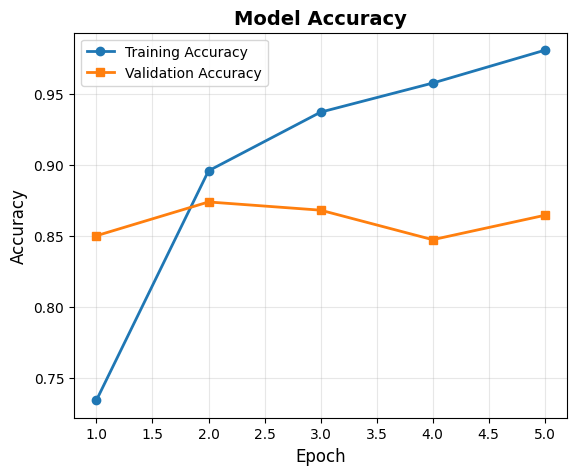

In [39]:
# Figure banao
plt.figure(figsize=(14, 5))

# Epochs ka range banao
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], marker='o', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, history.history['val_accuracy'], marker='s', label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


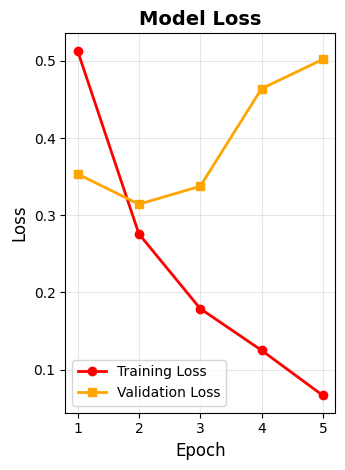

In [40]:
# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], marker='o', label='Training Loss', linewidth=2, color='red')
plt.plot(epochs_range, history.history['val_loss'], marker='s', label='Validation Loss', linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=200, bbox_inches='tight')
plt.show()

In [41]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=1)

print(f"\n{'='*70}")
print("TEST RESULTS")
print(f"{'='*70}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")
print(f"{'='*70}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8668 - loss: 0.3267

TEST RESULTS
  Test Accuracy: 0.8682 (86.82%)
  Test Loss: 0.3220


In [42]:
# Sare test reviews ke liye predictions nikalo
predictions_prob = model.predict(X_test_padded, verbose=1)

# Probability ko 0 ya 1 me convert karo
predictions = (predictions_prob > 0.5).astype(int)

# Statistics dekho
positive_predictions = np.sum(predictions)
negative_predictions = len(predictions) - positive_predictions

print(f"\n✓ Predictions complete!")
print(f"  Positive predictions: {positive_predictions} ({positive_predictions/len(predictions)*100:.2f}%)")
print(f"  Negative predictions: {negative_predictions} ({negative_predictions/len(predictions)*100:.2f}%)")

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step

✓ Predictions complete!
  Positive predictions: 13204 (52.82%)
  Negative predictions: 11796 (47.18%)


In [43]:
true_negative = 0
false_positive = 0
false_negative = 0
true_positive = 0

# Har prediction check karo
for i in range(len(y_test)):
    actual = y_test[i]
    predicted = predictions[i][0]

    if actual == 0 and predicted == 0:
        true_negative += 1
    elif actual == 0 and predicted == 1:
        false_positive += 1
    elif actual == 1 and predicted == 0:
        false_negative += 1
    elif actual == 1 and predicted == 1:
        true_positive += 1

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"               Neg    Pos")
print(f"Actual  Neg  [{true_negative:>6d} {false_positive:>6d}]")
print(f"        Pos  [{false_negative:>6d} {true_positive:>6d}]")


Confusion Matrix:
                 Predicted
               Neg    Pos
Actual  Neg  [ 10501   1999]
        Pos  [  1295  11205]


In [44]:
# Precision calculate karo
precision_positive = true_positive / (true_positive + false_positive)
precision_negative = true_negative / (true_negative + false_negative)

# Recall calculate karo
recall_positive = true_positive / (true_positive + false_negative)
recall_negative = true_negative / (true_negative + false_positive)

# F1 Score calculate karo
f1_positive = 2 * (precision_positive * recall_positive) / (precision_positive + recall_positive)
f1_negative = 2 * (precision_negative * recall_negative) / (precision_negative + recall_negative)

print(f"\nDetailed Metrics:")
print(f"  Precision (Positive): {precision_positive:.4f}")
print(f"  Precision (Negative): {precision_negative:.4f}")
print(f"  Recall (Positive):    {recall_positive:.4f}")
print(f"  Recall (Negative):    {recall_negative:.4f}")
print(f"  F1-Score (Positive):  {f1_positive:.4f}")
print(f"  F1-Score (Negative):  {f1_negative:.4f}")


Detailed Metrics:
  Precision (Positive): 0.8486
  Precision (Negative): 0.8902
  Recall (Positive):    0.8964
  Recall (Negative):    0.8401
  F1-Score (Positive):  0.8718
  F1-Score (Negative):  0.8644


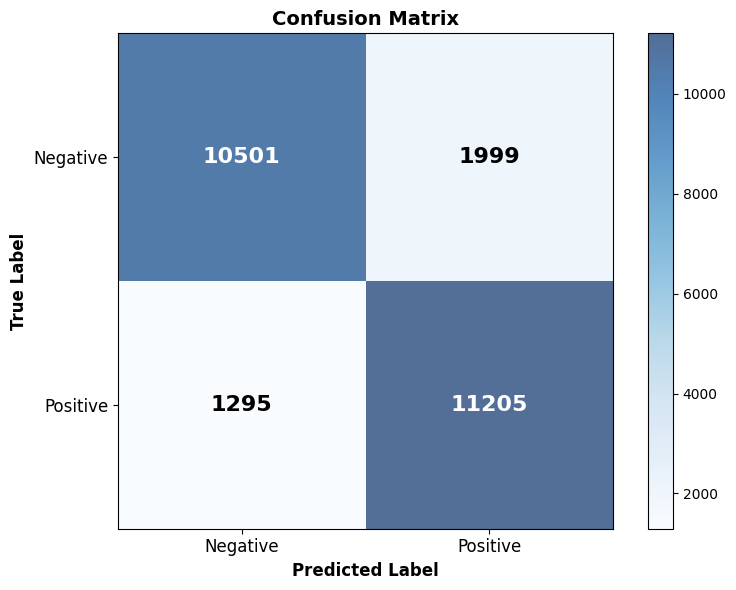

In [45]:
cm_array = np.array([[true_negative, false_positive],
                     [false_negative, true_positive]])

# Plot banao
plt.figure(figsize=(8, 6))
plt.imshow(cm_array, cmap='Blues', alpha=0.7)
plt.colorbar()

# Labels add karo
classes = ['Negative', 'Positive']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

# Values add karo cells me
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_array[i, j]),
                ha="center", va="center",
                fontsize=16, fontweight='bold',
                color="white" if cm_array[i, j] > cm_array.max()/2 else "black")

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

In [46]:
model.save('final_model.h5')

In [47]:
import os
if os.path.exists('final_model.h5'):
    size_mb = os.path.getsize('final_model.h5') / (1024 * 1024)
    print(f"\n✓ Model size: {size_mb:.2f} MB")


✓ Model size: 16.37 MB


In [48]:
from tensorflow.keras.models import load_model
loaded_model = load_model('best_model.h5')

In [49]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(X_test_padded, y_test, verbose=0)
print(f"\nLoaded model accuracy: {loaded_accuracy:.4f} ({loaded_accuracy*100:.2f}%)")


Loaded model accuracy: 0.8682 (86.82%)


In [50]:
test_review_text = "This movie was absolutely fantastic! Great acting and amazing story."

print(f"\nTest Review: {test_review_text}")



Test Review: This movie was absolutely fantastic! Great acting and amazing story.


In [51]:
# Review ko process karo
# Step 1: Lowercase banao aur words me split karo
words = test_review_text.lower().split()

# Step 2: Words ko numbers me convert karo
encoded_review = []
for word in words:
    if word in word_index:
        index = word_index[word] + 3  # 3 add karo (special tokens ke liye)
        if index < vocab_size:
            encoded_review.append(index)
    else:
        encoded_review.append(2)  # Unknown word

# Step 3: Padding add karo
padded_review = sequence.pad_sequences([encoded_review], maxlen=max_length)

# Step 4: Prediction nikalo
prediction = loaded_model.predict(padded_review, verbose=0)
prediction_value = prediction[0][0]

# Step 5: Result decide karo
if prediction_value >= 0.5:
    sentiment = "POSITIVE 😊"
    confidence = prediction_value * 100
else:
    sentiment = "NEGATIVE 😞"
    confidence = (1 - prediction_value) * 100

print(f"\n{'='*70}")
print(f"PREDICTION RESULT")
print(f"{'='*70}")
print(f"  Sentiment: {sentiment}")
print(f"  Confidence: {confidence:.2f}%")
print(f"  Raw Score: {prediction_value:.4f}")
print(f"{'='*70}")


PREDICTION RESULT
  Sentiment: POSITIVE 😊
  Confidence: 98.51%
  Raw Score: 0.9851


In [52]:
prediction

array([[0.9851135]], dtype=float32)

In [53]:
review_zero = "Disgusting, boring, meaningless and full of nonsense. Totally a waste of time, there is no logic in the movie and they are showing everything stupid in the movie. I felt that smashing my tv and my head."

In [54]:
# Review ko process karo
# Step 1: Lowercase banao aur words me split karo
words = review_zero.lower().split()

# Step 2: Words ko numbers me convert karo
encoded_review = []
for word in words:
    if word in word_index:
        index = word_index[word] + 3  # 3 add karo (special tokens ke liye)
        if index < vocab_size:
            encoded_review.append(index)
    else:
        encoded_review.append(2)  # Unknown word

# Step 3: Padding add karo
padded_review = sequence.pad_sequences([encoded_review], maxlen=max_length)

# Step 4: Prediction nikalo
prediction = loaded_model.predict(padded_review, verbose=0)
prediction_value = prediction[0][0]

# Step 5: Result decide karo
if prediction_value >= 0.5:
    sentiment = "POSITIVE 😊"
    confidence = prediction_value * 100
else:
    sentiment = "NEGATIVE 😞"
    confidence = (1 - prediction_value) * 100

print(f"\n{'='*70}")
print(f"PREDICTION RESULT")
print(f"{'='*70}")
print(f"  Sentiment: {sentiment}")
print(f"  Confidence: {confidence:.2f}%")
print(f"  Raw Score: {prediction_value:.4f}")
print(f"{'='*70}")


PREDICTION RESULT
  Sentiment: NEGATIVE 😞
  Confidence: 87.16%
  Raw Score: 0.1284


In [ ]:
# ============================================================================
# IMDB SENTIMENT ANALYSIS USING GRU - SIMPLE LINE BY LINE CODE
# No Functions | No Classes | Easy to Understand
# Google Colab Ready - Just Copy & Run!
# ============================================================================

# ----------------------------------------------------------------------------
# CELL 1: Import karo sab libraries
# ----------------------------------------------------------------------------
print("="*70)
print("STEP 1: Libraries import kar rahe hain...")
print("="*70)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("\n✓ Sab libraries import ho gayi!")
print(f"TensorFlow version: {tf.__version__}")

# GPU check karo
if tf.config.list_physical_devices('GPU'):
    print("✓ GPU mil gaya - Fast training hogi!")
else:
    print("ℹ GPU nahi mila - CPU use hoga")


# ----------------------------------------------------------------------------
# CELL 2: Settings set karo (GRU ke liye)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 2: GRU model ke liye settings set kar rahe hain...")
print("="*70)

# Hyperparameters
vocab_size = 10000      # Kitne words use karne hain
max_length = 200        # Review kitna lamba ho sakta hai
embedding_dim = 128     # Word embedding ka size
gru_units = 64          # GRU layer me kitne neurons (LSTM ki jagah GRU)
batch_size = 128        # Ek baar me kitne reviews train karna
epochs = 10             # Kitni baar pura data dekhna hai

print(f"\nGRU Model Settings:")
print(f"  Vocabulary size: {vocab_size}")
print(f"  Max review length: {max_length}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  GRU units: {gru_units} (LSTM ki jagah GRU use kar rahe hain)")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {epochs}")


# ----------------------------------------------------------------------------
# CELL 3: Data load karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 3: IMDB dataset load kar rahe hain...")
print("="*70)

# IMDB dataset download aur load karo
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"\n✓ Data load ho gaya!")
print(f"  Training reviews: {len(X_train)}")
print(f"  Testing reviews: {len(X_test)}")
print(f"  Total reviews: {len(X_train) + len(X_test)}")

# Pehla review dekho
print(f"\nPehle review ka data:")
print(f"  Length: {len(X_train[0])} words")
print(f"  Label: {y_train[0]} (0=Negative, 1=Positive)")
print(f"  First 10 words (encoded): {X_train[0][:10]}")


# ----------------------------------------------------------------------------
# CELL 4: Labels dekho
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 4: Labels check kar rahe hain...")
print("="*70)

# Kitne positive aur negative reviews hain
negative_count = np.sum(y_train == 0)
positive_count = np.sum(y_train == 1)

print(f"\nTraining data me:")
print(f"  Negative reviews: {negative_count} ({negative_count/len(y_train)*100:.1f}%)")
print(f"  Positive reviews: {positive_count} ({positive_count/len(y_train)*100:.1f}%)")


# ----------------------------------------------------------------------------
# CELL 5: Word index load karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 5: Word index load kar rahe hain...")
print("="*70)

# Word to number mapping
word_index = imdb.get_word_index()

# Number to word mapping banao (ulta)
reverse_word_index = {}
for word, index in word_index.items():
    reverse_word_index[index + 3] = word

# Special tokens add karo
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'

print(f"\n✓ Word index load ho gaya!")
print(f"  Total words in dictionary: {len(word_index)}")


# ----------------------------------------------------------------------------
# CELL 6: Ek review decode karke dekho
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 6: Sample review decode kar rahe hain...")
print("="*70)

# Pehla review ko words me convert karo
decoded_review = ""
for num in X_train[0]:
    if num != 0:  # Padding skip karo
        decoded_review += reverse_word_index.get(num, '?') + " "

print(f"\nDecoded review (pehle 200 characters):")
print(f"{decoded_review[:200]}...")
print(f"\nLabel: {'Positive' if y_train[0] == 1 else 'Negative'}")


# ----------------------------------------------------------------------------
# CELL 7: Data visualization
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 7: Data visualize kar rahe hain...")
print("="*70)

# Review lengths calculate karo
review_lengths = []
for review in X_train:
    review_lengths.append(len(review))

# Plot banao
plt.figure(figsize=(12, 4))

# Plot 1: Review lengths
plt.subplot(1, 2, 1)
plt.hist(review_lengths, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length = {max_length}')
plt.xlabel('Review Length (words)')
plt.ylabel('Count')
plt.title('GRU Model - Review Length Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Label distribution
plt.subplot(1, 2, 2)
labels = ['Negative', 'Positive']
counts = [negative_count, positive_count]
colors = ['red', 'green']
plt.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Count')
plt.title('GRU Model - Label Distribution')
plt.grid(True, alpha=0.3, axis='y')

# Numbers add karo bars pe
for i, count in enumerate(counts):
    plt.text(i, count + 200, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('gru_data_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ Visualization complete!")
print("✓ Plot saved: gru_data_distribution.png")


# ----------------------------------------------------------------------------
# CELL 8: Sequences ko pad karo (same length banana)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 8: Sequences pad kar rahe hain...")
print("="*70)

# Sab reviews ko same length ka banao
X_train_padded = sequence.pad_sequences(X_train, maxlen=max_length)
X_test_padded = sequence.pad_sequences(X_test, maxlen=max_length)

print(f"\n✓ Padding complete!")
print(f"  X_train shape: {X_train_padded.shape}")
print(f"  X_test shape: {X_test_padded.shape}")

# Example dekho
print(f"\nPehle review me padding:")
print(f"  Original length: {len(X_train[0])}")
print(f"  Padded length: {len(X_train_padded[0])}")
print(f"  Padded review start: {X_train_padded[0][:10]}")
print(f"  Padded review end: {X_train_padded[0][-10:]}")


# ----------------------------------------------------------------------------
# CELL 9: GRU Model banao - Architecture define karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 9: GRU model bana rahe hain...")
print("="*70)
print("Note: GRU LSTM se thoda fast hai aur kam parameters use karta hai!")

# Empty model banao
gru_model = Sequential()

# Layer 1: Embedding layer - words ko numbers se vectors me convert karta hai
gru_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# Layer 2: Bidirectional GRU - aage aur peeche dono taraf se data padhta hai
# GRU LSTM se simple hai - kam gates use karta hai (2 gates: reset aur update)
gru_model.add(Bidirectional(GRU(gru_units, return_sequences=True)))

# Layer 3: Dropout - overfitting rokne ke liye
gru_model.add(Dropout(0.5))

# Layer 4: Ek aur Bidirectional GRU layer
gru_model.add(Bidirectional(GRU(gru_units // 2)))

# Layer 5: Dropout layer
gru_model.add(Dropout(0.5))

# Layer 6: Dense layer - fully connected layer
gru_model.add(Dense(64, activation='relu'))

# Layer 7: Dropout
gru_model.add(Dropout(0.3))

# Layer 8: Output layer - final prediction (0 ya 1)
gru_model.add(Dense(1, activation='sigmoid'))

print("\n✓ GRU model architecture ready!")
print("\nGRU vs LSTM:")
print("  • GRU: 2 gates (reset, update) - SIMPLE & FAST")
print("  • LSTM: 3 gates (input, forget, output) - COMPLEX")
print("  • GRU: Kam parameters - Kam memory use karta hai")
print("  • GRU: Training fast hoti hai")


# ----------------------------------------------------------------------------
# CELL 10: Model summary dekho
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 10: GRU Model summary dekh rahe hain...")
print("="*70)

# Explicitly build the model before calling summary or counting parameters
gru_model.build(input_shape=(None, max_length))

# Model ki puri details print karo
gru_model.summary()

# Parameters count karo
total_params = gru_model.count_params()
print(f"\n✓ Total parameters in GRU model: {total_params:,}")
print("Note: GRU model me LSTM se kam parameters hote hain!")


# ----------------------------------------------------------------------------
# CELL 11: Model compile karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 11: GRU Model compile kar rahe hain...")
print("="*70)

# Model ko compile karo - optimizer, loss function, aur metrics set karo
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n✓ GRU Model compiled!")
print("  Optimizer: Adam")
print("  Loss: Binary Crossentropy")
print("  Metrics: Accuracy")


# ----------------------------------------------------------------------------
# CELL 12: Callbacks setup karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 12: Training callbacks setup kar rahe hain...")
print("="*70)

# Early stopping - agar improvement nahi ho raha to training rok do
early_stop_gru = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint - best model save karo
checkpoint_gru = ModelCheckpoint(
    'best_gru_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Learning rate reduction - agar learning slow ho to LR kam karo
reduce_lr_gru = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# Sab callbacks ko ek list me dalo
callbacks_gru = [early_stop_gru, checkpoint_gru, reduce_lr_gru]

print("\n✓ Callbacks ready!")
print("  1. Early Stopping (patience=3)")
print("  2. Model Checkpoint (save best GRU model)")
print("  3. Learning Rate Reduction")


# ----------------------------------------------------------------------------
# CELL 13: GRU MODEL TRAINING - Sabse important step!
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 13: GRU MODEL TRAINING START...")
print("="*70)
print(f"\nTraining GRU model for {epochs} epochs...")
print("GRU usually LSTM se thoda fast train hota hai!")
print("Patience rakho!\n")

# GRU model ko train karo
gru_history = gru_model.fit(
    X_train_padded,           # Training data
    y_train,                  # Training labels
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=callbacks_gru,
    verbose=1
)

print("\n" + "="*70)
print("✓ GRU MODEL TRAINING COMPLETE!")
print("="*70)


# ----------------------------------------------------------------------------
# CELL 14: Training history dekho
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 14: GRU Training results dekh rahe hain...")
print("="*70)

# Last epoch ke results nikalo
gru_final_train_accuracy = gru_history.history['accuracy'][-1]
gru_final_val_accuracy = gru_history.history['val_accuracy'][-1]
gru_final_train_loss = gru_history.history['loss'][-1]
gru_final_val_loss = gru_history.history['val_loss'][-1]

print(f"\nGRU Model - Final Results:")
print(f"  Training Accuracy: {gru_final_train_accuracy:.4f} ({gru_final_train_accuracy*100:.2f}%)")
print(f"  Validation Accuracy: {gru_final_val_accuracy:.4f} ({gru_final_val_accuracy*100:.2f}%)")
print(f"  Training Loss: {gru_final_train_loss:.4f}")
print(f"  Validation Loss: {gru_final_val_loss:.4f}")

# Best epoch nikalo
gru_best_epoch = np.argmax(gru_history.history['val_accuracy']) + 1
gru_best_accuracy = max(gru_history.history['val_accuracy'])
print(f"\n  Best Validation Accuracy: {gru_best_accuracy:.4f} at epoch {gru_best_epoch}")


# ----------------------------------------------------------------------------
# CELL 15: Training plots banao
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 15: GRU Training plots bana rahe hain...")
print("="*70)

# Figure banao
plt.figure(figsize=(14, 5))

# Epochs ka range banao
gru_epochs_range = range(1, len(gru_history.history['accuracy']) + 1)

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(gru_epochs_range, gru_history.history['accuracy'], marker='o',
         label='Training Accuracy', linewidth=2, color='purple')
plt.plot(gru_epochs_range, gru_history.history['val_accuracy'], marker='s',
         label='Validation Accuracy', linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('GRU Model - Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(gru_epochs_range, gru_history.history['loss'], marker='o',
         label='Training Loss', linewidth=2, color='red')
plt.plot(gru_epochs_range, gru_history.history['val_loss'], marker='s',
         label='Validation Loss', linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('GRU Model - Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gru_training_history.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ GRU Training plots saved: gru_training_history.png")


# ----------------------------------------------------------------------------
# CELL 16: Test data pe evaluate karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 16: Test data pe GRU model evaluate kar rahe hain...")
print("="*70)

# Test set pe model evaluate karo
gru_test_loss, gru_test_accuracy = gru_model.evaluate(X_test_padded, y_test, verbose=1)

print(f"\n{'='*70}")
print("GRU MODEL - TEST RESULTS")
print(f"{'='*70}")
print(f"  Test Accuracy: {gru_test_accuracy:.4f} ({gru_test_accuracy*100:.2f}%)")
print(f"  Test Loss: {gru_test_loss:.4f}")
print(f"{'='*70}")


# ----------------------------------------------------------------------------
# CELL 17: Predictions generate karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 17: Test data pe predictions bana rahe hain...")
print("="*70)

# Sare test reviews ke liye predictions nikalo
gru_predictions_prob = gru_model.predict(X_test_padded, verbose=1)

# Probability ko 0 ya 1 me convert karo
gru_predictions = (gru_predictions_prob > 0.5).astype(int)

# Statistics dekho
gru_positive_predictions = np.sum(gru_predictions)
gru_negative_predictions = len(gru_predictions) - gru_positive_predictions

print(f"\n✓ Predictions complete!")
print(f"  Positive predictions: {gru_positive_predictions} ({gru_positive_predictions/len(gru_predictions)*100:.2f}%)")
print(f"  Negative predictions: {gru_negative_predictions} ({gru_negative_predictions/len(gru_predictions)*100:.2f}%)")


# ----------------------------------------------------------------------------
# CELL 18: Confusion Matrix banao
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 18: GRU Model - Confusion Matrix bana rahe hain...")
print("="*70)

# Confusion matrix manually calculate karo
gru_true_negative = 0
gru_false_positive = 0
gru_false_negative = 0
gru_true_positive = 0

# Har prediction check karo
for i in range(len(y_test)):
    actual = y_test[i]
    predicted = gru_predictions[i][0]

    if actual == 0 and predicted == 0:
        gru_true_negative += 1
    elif actual == 0 and predicted == 1:
        gru_false_positive += 1
    elif actual == 1 and predicted == 0:
        gru_false_negative += 1
    elif actual == 1 and predicted == 1:
        gru_true_positive += 1

print(f"\nGRU Model - Confusion Matrix:")
print(f"                 Predicted")
print(f"               Neg    Pos")
print(f"Actual  Neg  [{gru_true_negative:>6d} {gru_false_positive:>6d}]")
print(f"        Pos  [{gru_false_negative:>6d} {gru_true_positive:>6d}]")


# ----------------------------------------------------------------------------
# CELL 19: Metrics calculate karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 19: GRU Model - Detailed metrics calculate kar rahe hain...")
print("="*70)

# Precision calculate karo
gru_precision_positive = gru_true_positive / (gru_true_positive + gru_false_positive)
gru_precision_negative = gru_true_negative / (gru_true_negative + gru_false_negative)

# Recall calculate karo
gru_recall_positive = gru_true_positive / (gru_true_positive + gru_false_negative)
gru_recall_negative = gru_true_negative / (gru_true_negative + gru_false_positive)

# F1 Score calculate karo
gru_f1_positive = 2 * (gru_precision_positive * gru_recall_positive) / (gru_precision_positive + gru_recall_positive)
gru_f1_negative = 2 * (gru_precision_negative * gru_recall_negative) / (gru_precision_negative + gru_recall_negative)

print(f"\nGRU Model - Detailed Metrics:")
print(f"  Precision (Positive): {gru_precision_positive:.4f}")
print(f"  Precision (Negative): {gru_precision_negative:.4f}")
print(f"  Recall (Positive):    {gru_recall_positive:.4f}")
print(f"  Recall (Negative):    {gru_recall_negative:.4f}")
print(f"  F1-Score (Positive):  {gru_f1_positive:.4f}")
print(f"  F1-Score (Negative):  {gru_f1_negative:.4f}")


# ----------------------------------------------------------------------------
# CELL 20: Confusion matrix plot banao
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 20: GRU Model - Confusion matrix visualize kar rahe hain...")
print("="*70)

# Confusion matrix array banao
gru_cm_array = np.array([[gru_true_negative, gru_false_positive],
                         [gru_false_negative, gru_true_positive]])

# Plot banao
plt.figure(figsize=(8, 6))
plt.imshow(gru_cm_array, cmap='Purples', alpha=0.7)
plt.colorbar()

# Labels add karo
classes = ['Negative', 'Positive']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

# Values add karo cells me
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(gru_cm_array[i, j]),
                ha="center", va="center",
                fontsize=16, fontweight='bold',
                color="white" if gru_cm_array[i, j] > gru_cm_array.max()/2 else "black")

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('GRU Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gru_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ GRU Confusion matrix saved: gru_confusion_matrix.png")


# ----------------------------------------------------------------------------
# CELL 21: Model save karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 21: GRU Model save kar rahe hain...")
print("="*70)

# Final GRU model save karo
gru_model.save('final_gru_model.h5')

print("\n✓ GRU Models saved!")
print("  1. best_gru_model.h5 (best checkpoint during training)")
print("  2. final_gru_model.h5 (final trained GRU model)")

# File size check karo
import os
if os.path.exists('final_gru_model.h5'):
    size_mb = os.path.getsize('final_gru_model.h5') / (1024 * 1024)
    print(f"\n✓ GRU Model size: {size_mb:.2f} MB")
    print("Note: GRU model LSTM se chota hota hai (kam parameters)!")


# ----------------------------------------------------------------------------
# CELL 22: Model load karke test karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 22: Saved GRU model load kar rahe hain...")
print("="*70)

# Load the best GRU model
from tensorflow.keras.models import load_model
loaded_gru_model = load_model('best_gru_model.h5')

print("\n✓ GRU Model loaded successfully!")

# Verify karke dekho
loaded_gru_loss, loaded_gru_accuracy = loaded_gru_model.evaluate(X_test_padded, y_test, verbose=0)
print(f"\nLoaded GRU model accuracy: {loaded_gru_accuracy:.4f} ({loaded_gru_accuracy*100:.2f}%)")


# ----------------------------------------------------------------------------
# CELL 23: Naye review pe prediction karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 23: GRU Model se custom review pe prediction kar rahe hain...")
print("="*70)

# Test review likho
gru_test_review_text = "This movie was absolutely fantastic! Great acting and amazing story."

print(f"\nTest Review: {gru_test_review_text}")

# Review ko process karo
# Step 1: Lowercase banao aur words me split karo
gru_words = gru_test_review_text.lower().split()

# Step 2: Words ko numbers me convert karo
gru_encoded_review = []
for word in gru_words:
    if word in word_index:
        index = word_index[word] + 3  # 3 add karo (special tokens ke liye)
        if index < vocab_size:
            gru_encoded_review.append(index)
    else:
        gru_encoded_review.append(2)  # Unknown word

# Step 3: Padding add karo
gru_padded_review = sequence.pad_sequences([gru_encoded_review], maxlen=max_length)

# Step 4: Prediction nikalo
gru_prediction = loaded_gru_model.predict(gru_padded_review, verbose=0)
gru_prediction_value = gru_prediction[0][0]

# Step 5: Result decide karo
if gru_prediction_value >= 0.5:
    gru_sentiment = "POSITIVE 😊"
    gru_confidence = gru_prediction_value * 100
else:
    gru_sentiment = "NEGATIVE 😞"
    gru_confidence = (1 - gru_prediction_value) * 100

print(f"\n{'='*70}")
print(f"GRU MODEL - PREDICTION RESULT")
print(f"{'='*70}")
print(f"  Sentiment: {gru_sentiment}")
print(f"  Confidence: {gru_confidence:.2f}%")
print(f"  Raw Score: {gru_prediction_value:.4f}")
print(f"{'='*70}")


# ----------------------------------------------------------------------------
# CELL 24: Multiple custom reviews test karo
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 24: GRU Model se multiple reviews test kar rahe hain...")
print("="*70)

# Multiple test reviews
gru_test_reviews = [
    "This movie was terrible and boring. Complete waste of time.",
    "Amazing film! Best movie I have seen this year. Highly recommended!",
    "It was okay. Not great but not bad either.",
    "Absolutely loved it! Perfect in every way.",
    "Worst movie ever. Don't waste your money.",
    "Brilliant cinematography and outstanding performances!",
    "Disappointing and predictable. Expected much better."
]

print("\nGRU Model - Testing multiple reviews:\n")

# Har review ke liye prediction nikalo
for idx, review_text in enumerate(gru_test_reviews, 1):
    # Words me split karo
    words = review_text.lower().split()

    # Encode karo
    encoded = []
    for word in words:
        if word in word_index:
            index = word_index[word] + 3
            if index < vocab_size:
                encoded.append(index)
        else:
            encoded.append(2)

    # Pad karo
    padded = sequence.pad_sequences([encoded], maxlen=max_length)

    # Predict karo
    pred = loaded_gru_model.predict(padded, verbose=0)[0][0]

    # Sentiment decide karo
    if pred >= 0.5:
        sent = "POSITIVE 😊"
        conf = pred * 100
    else:
        sent = "NEGATIVE 😞"
        conf = (1 - pred) * 100

    # Print karo
    print(f"Review {idx}:")
    print(f"  Text: {review_text}")
    print(f"  Prediction: {sent}")
    print(f"  Confidence: {conf:.2f}%")
    print()


# ----------------------------------------------------------------------------
# CELL 25: GRU vs LSTM Comparison
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 25: GRU MODEL SUMMARY & COMPARISON")
print("="*70)

print(f"""
✅ GRU Model Successfully Completed!

📊 GRU Model Performance:
  • Test Accuracy: {gru_test_accuracy*100:.2f}%
  • Precision: {gru_precision_positive*100:.2f}%
  • Recall: {gru_recall_positive*100:.2f}%
  • F1-Score: {gru_f1_positive*100:.2f}%
  • Total Parameters: {total_params:,}

📁 Generated Files:
  • best_gru_model.h5 - Best GRU model checkpoint
  • final_gru_model.h5 - Final trained GRU model
  • gru_training_history.png - Training plots
  • gru_confusion_matrix.png - Confusion matrix
  • gru_data_distribution.png - Data visualization

🔍 GRU vs LSTM Comparison:

  GRU (Gated Recurrent Unit):
  ✓ 2 gates (Reset, Update)
  ✓ Simpler architecture
  ✓ Fewer parameters
  ✓ Faster training
  ✓ Less memory usage
  ✓ Good for simpler sequences

  LSTM (Long Short-Term Memory):
  ✓ 3 gates (Input, Forget, Output)
  ✓ More complex architecture
  ✓ More parameters
  ✓ Slower training
  ✓ More memory usage
  ✓ Better for complex sequences

💡 When to use GRU:
  • Smaller datasets
  • Need faster training
  • Limited computational resources
  • Simpler sequence patterns
  • When LSTM overfits

💡 When to use LSTM:
  • Larger datasets
  • Complex sequence patterns
  • Long-term dependencies
  • Need more model capacity
  • Better accuracy needed

🎯 For IMDB Dataset:
  Both GRU and LSTM give similar accuracy (~87-89%)
  GRU trains faster and uses less memory
  LSTM might capture slightly more complex patterns
""")

print("="*70)
print("GRU MODEL - CODE EXECUTION COMPLETE! 🎉")
print("="*70)
print("\nNext Steps:")
print("  • Compare GRU accuracy with LSTM")
print("  • Try both models on your own reviews")
print("  • Experiment with hyperparameters")
print("  • Deploy the better performing model")
print("\nHappy Predicting with GRU! 🚀")
print("="*70)